# Project: Wildfire Prediction

### Set up imports

In [55]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

### Load the data

In [2]:
# Import data from file, only using the first 5000 rows
wildfires_df = pd.read_csv('Dataset-A_US_Wildfire.csv', nrows = 5000)

### Inspect the data

In [3]:
# Look at the size (rows, columns)
wildfires_df.shape

(5000, 19)

In [4]:
# Look at the columns
print("Columns:", wildfires_df.columns)

Columns: Index(['latitude', 'longitude', 'datetime', 'Wildfire', 'pr', 'rmax', 'rmin',
       'sph', 'srad', 'tmmn', 'tmmx', 'vs', 'bi', 'fm100', 'fm1000', 'erc',
       'etr', 'pet', 'vpd'],
      dtype='str')


In [5]:
# Look at the first 5 rows
wildfires_df.head()

,latitude,longitude,datetime,Wildfire,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
0,48.128431,-97.276685,2018-08-15,No,0.0,78.6,14.9,0.00582,272.6,282.0,301.6,3.0,40.0,10.2,12.2,54.0,7.5,5.5,1.59
1,48.128431,-97.276685,2018-08-16,No,0.0,80.4,13.9,0.00676,264.0,283.9,304.9,3.0,40.0,9.7,12.0,56.0,8.2,5.9,1.93
2,48.128431,-97.276685,2018-08-17,No,0.0,70.9,20.4,0.00672,265.6,285.8,300.7,3.1,40.0,9.2,11.9,56.0,7.2,5.3,1.51
3,48.128431,-97.276685,2018-08-18,No,5.0,65.2,19.4,0.00756,261.4,289.0,303.3,5.1,0.0,9.9,12.0,40.0,10.0,6.9,1.85
4,48.128431,-97.276685,2018-08-19,No,0.0,100.0,42.2,0.00895,166.8,283.8,296.5,4.7,41.0,11.8,12.1,47.0,4.6,3.4,0.66


## Columns:
- pr = Precipitation
- rmax = Max daily relative humidity
- rmin = Min daily relative humidity
- sph = Specific humidity
- srad = Solar radiation
- tmmn = Min daily temperature
- tmmx = Max daily temperature
- vs = Wind speed
- bi = Burning index
- fm100 = 100-hr dead fuel moisture
- fm1000 = 1000-hr dead fuel moisture
- erc = Energy Release Component
- etr = Actual evapotranspiration
- pet = Potential evapotranspiration
- vpd = Vapor pressure deficit

In [6]:
# Look at the number of occurrences of wildfires
wildfires_df['Wildfire'].value_counts()

Wildfire
No     4775
Yes     225
Name: count, dtype: int64

In [33]:
# Data preprocessing: drop any missing values
wildfires_df = wildfires_df.dropna()

### Split the data for training and testing

In [7]:
# Assign values to X and Y
X = wildfires_df[['latitude', 'longitude', 'pr', 'rmax', 'rmin',
       'sph', 'srad', 'tmmn', 'tmmx', 'vs', 'bi', 'fm100', 'fm1000', 'erc',
       'etr', 'pet', 'vpd']]      
y = wildfires_df['Wildfire']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

### Define the hyperparameter grid

In [8]:
hyperparam_grid = {
	'criterion': ['gini', 'entropy'],
	'max_depth': [2, 4, 8],
	'max_features': ['sqrt', 'log2'],
	'n_estimators': [30, 60, 90]
}

### Define the model and grid search

In [44]:
rf_classifier = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_classifier, param_grid=hyperparam_grid, cv=2)

### Run the grid search and get the best hyperparameters

In [62]:
grid_search.fit(X_train, y_train)

best_hyperparams = grid_search.best_params_

print(best_hyperparams)

{'criterion': 'entropy', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 30}


### Define the new model with the best hyperparameters

In [57]:
wildfires_rf_model = RandomForestClassifier(
    criterion= 'entropy',
    max_depth= 8,
    max_features= 'sqrt',
    n_estimators= 30,
    random_state=42
)

wildfires_rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

### Generate test set predictions

In [58]:
y_pred = wildfires_rf_model.predict(X_test)

y_pred

array(['No', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(2500,), dtype=object)

### Compute the accuracy

In [59]:
acc = accuracy_score(y_test, y_pred)

print('Accuracy:',acc)

Accuracy: 0.9536


### Evaluate the results with classification report

In [60]:
print('Classification Report:\n',(classification_report(y_test, y_pred)))

Classification Report:
               precision    recall  f1-score   support

          No       0.95      1.00      0.98      2385
         Yes       0.00      0.00      0.00       115

    accuracy                           0.95      2500
   macro avg       0.48      0.50      0.49      2500
weighted avg       0.91      0.95      0.93      2500



### Get and plot feature importances

      Feature  Importance
0    latitude    0.126848
1   longitude    0.117582
12     fm1000    0.094763
5         sph    0.088502
13        erc    0.070591
11      fm100    0.066998
6        srad    0.055759
4        rmin    0.054241
7        tmmn    0.051209
8        tmmx    0.043755
14        etr    0.043549
3        rmax    0.038893
16        vpd    0.037316
10         bi    0.036205
15        pet    0.035039
9          vs    0.028427
2          pr    0.010323


Text(0, 0.5, 'Importance')

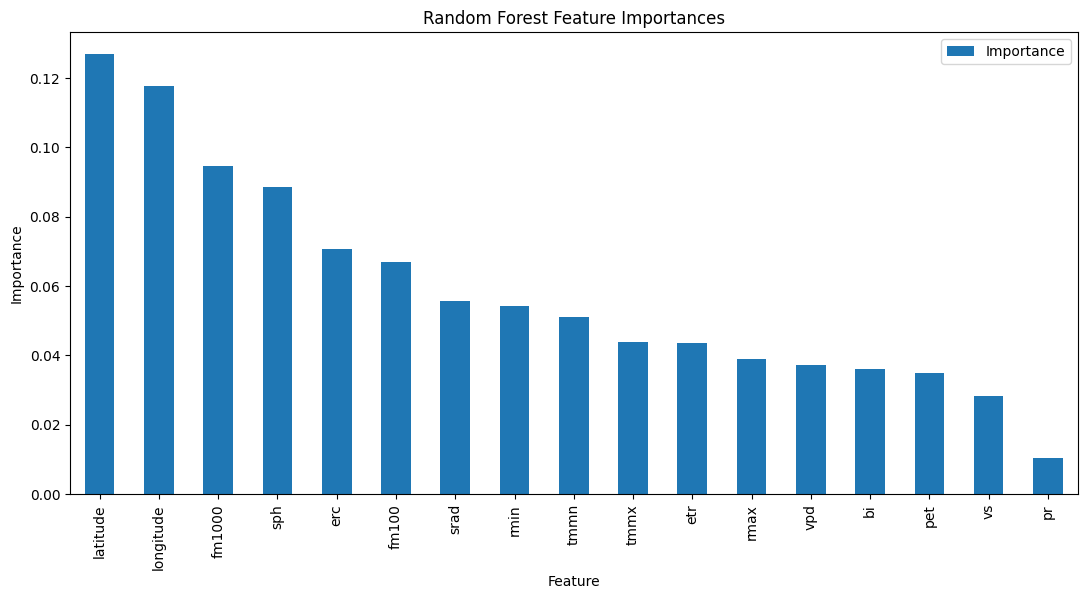

In [61]:
# Get feature importances
feature_importances = wildfires_rf_model.feature_importances_

# Convert to a dataframe
feature_importance_df = pd.DataFrame({
	'Feature': X.columns,
	'Importance': feature_importances
})

# Sort the dataframe from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

print(feature_importance_df)

# Plot the feature importances
feature_importance_df.plot.bar(x='Feature', y='Importance', figsize=(13,6))
plt.title('Random Forest Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance')